# Random Wall Experiments
Comparing **Value Iteration**, **Q-Learning**, **SARSA**, and **Dyna-Q** on a 19×19 grid
with randomly placed wall blocks at ~20% density.

Start: `(0, 0)` — Goal: `(18, 18)`. Walls are placed uniformly at random (excluding start/goal),
then a connectivity check ensures the goal is reachable; blocked grids are re-seeded.

In [10]:
from __future__ import annotations

import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import (
    greedy_policy_from_V, evaluate,
    plot_env, plot_policy, plot_value_heatmap,
)
from helpers.rl import value_iteration, q_learning, sarsa
from helpers.dynaq import dyna_q

## Wall generation

In [11]:
from collections import deque

def random_walls(rows: int, cols: int, density: float = 0.20,
                 start=(0, 0), goal=None, seed: int = 0) -> set:
    """Place walls uniformly at random. Retries until start and goal are connected."""
    if goal is None:
        goal = (rows - 1, cols - 1)
    rng = random.Random(seed)
    candidates = [(r, c) for r in range(rows) for c in range(cols)
                  if (r, c) not in (start, goal)]
    n_walls = int(len(candidates) * density)

    for attempt in range(1000):
        walls = set(rng.sample(candidates, n_walls))
        # BFS connectivity check
        visited, q = {start}, deque([start])
        while q:
            r, c = q.popleft()
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nb = (r+dr, c+dc)
                if 0 <= nb[0] < rows and 0 <= nb[1] < cols and nb not in walls and nb not in visited:
                    visited.add(nb); q.append(nb)
        if goal in visited:
            print(f"Generated in {attempt+1} attempt(s).")
            return walls
        rng = random.Random(seed + attempt + 1)
    raise RuntimeError("Could not generate a connected grid after 1000 attempts.")


NUM_ROWS, NUM_COLS = 10, 10
START, GOAL = (0, 0), (NUM_ROWS - 1, NUM_COLS - 1)
WALL_DENSITY = 0.30

WALL_CELLS = random_walls(NUM_ROWS, NUM_COLS, density=WALL_DENSITY,
                           start=START, goal=GOAL, seed=67)
free = NUM_ROWS * NUM_COLS - len(WALL_CELLS)
print(f"Grid: {NUM_ROWS}×{NUM_COLS}   Walls: {len(WALL_CELLS)} ({len(WALL_CELLS)/(NUM_ROWS*NUM_COLS):.1%})   Free: {free}")

Generated in 2 attempt(s).
Grid: 10×10   Walls: 29 (29.0%)   Free: 71


## Environment

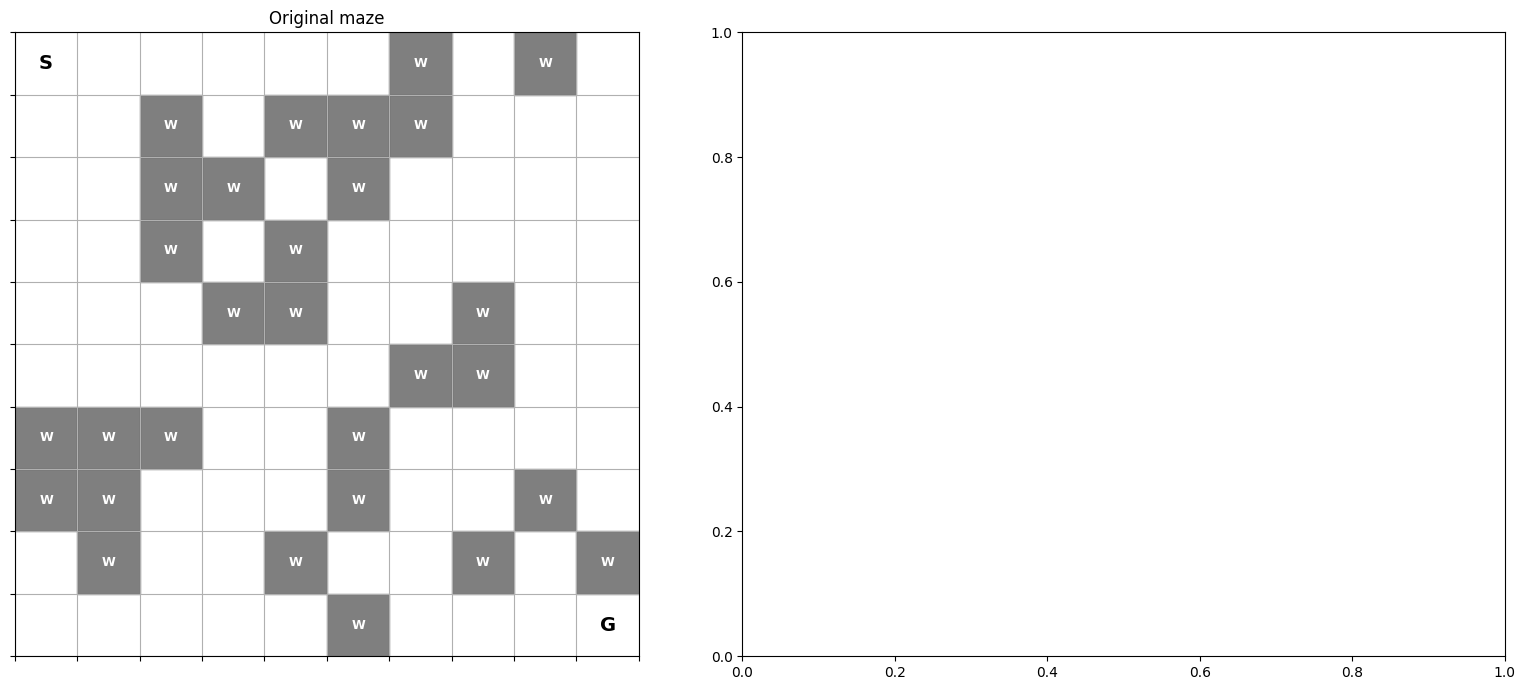

In [ ]:
SLIP_PROB   = 0.05
STEP_REWARD = -1.0
GOAL_REWARD = 10.0
MAX_STEPS   = 800
GAMMA       = 0.995
SEED        = 42

def make_env(wall_fields=None):
    return SlipperyGridWorld(
        rows=NUM_ROWS, cols=NUM_COLS,
        start=START, goal=GOAL,
        slip_prob=SLIP_PROB,
        step_reward=STEP_REWARD,
        goal_reward=GOAL_REWARD,
        wall_fields=wall_fields if wall_fields is not None else WALL_CELLS,
        max_steps=MAX_STEPS,
        seed=SEED,
    )

env = make_env()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_env(env, title="Original maze", ax=axes[0])
plt.tight_layout()
plt.savefig("maze_envs.png", dpi=150)
plt.show()

## Value Iteration

In [13]:
env_vi = make_env()
V_vi, vi_iters = value_iteration(env_vi, max_iterations=2000, gamma=GAMMA, threshold=1e-6)
pi_vi = greedy_policy_from_V(V_vi, env_vi, GAMMA)
metrics_vi = evaluate(env_vi, policy=pi_vi, n_episodes=300, seed=SEED)
print(f"Converged in {vi_iters} iterations   Metrics: {metrics_vi}")

Converged in 2000 iterations   Metrics: {'avg_return': -21.8, 'std_return': 1.6593, 'success_rate': 1.0, 'avg_steps': 27.8}


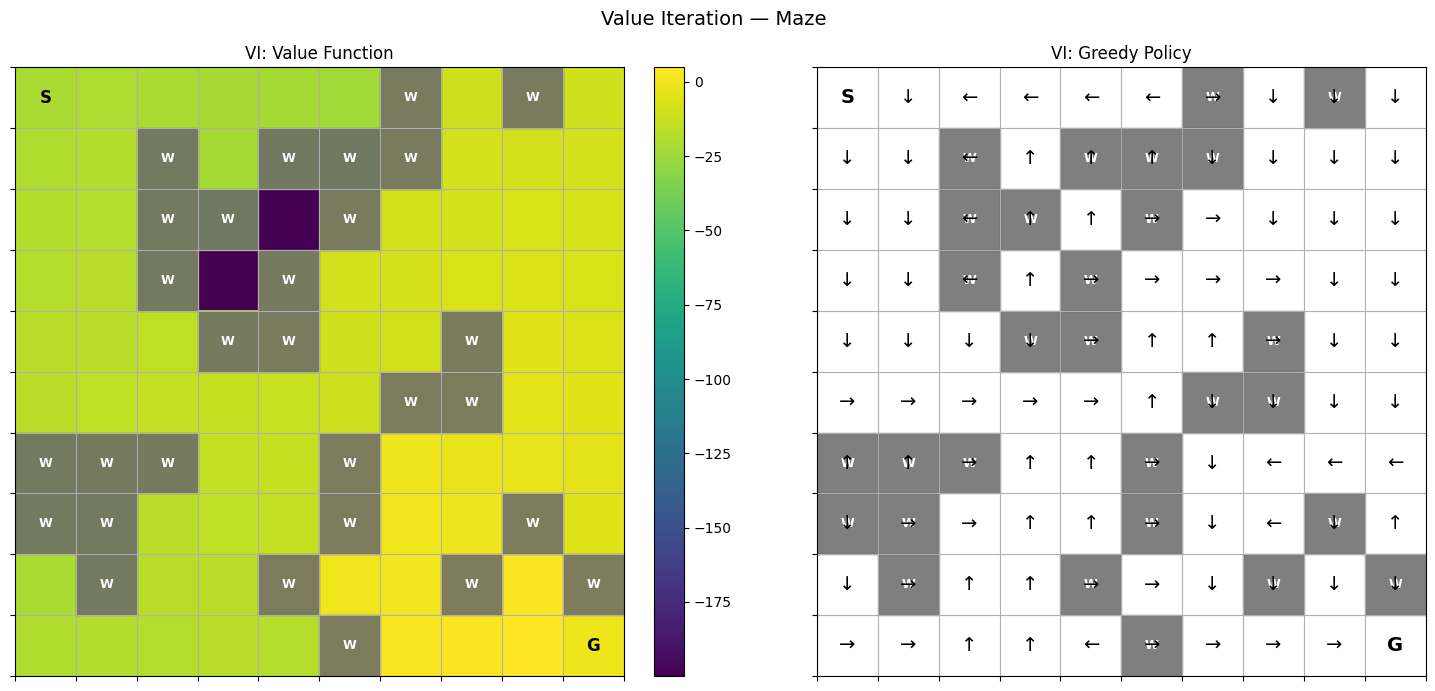

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_value_heatmap(env_vi, V_vi, title="VI: Value Function", ax=axes[0])
plot_policy(env_vi, pi_vi, title="VI: Greedy Policy", ax=axes[1])
plt.suptitle("Value Iteration — Maze", fontsize=14)
plt.tight_layout()
plt.savefig("maze_vi.png", dpi=150)
plt.show()

## Q-Learning, SARSA, Dyna-Q

In [15]:
N_EPISODES    = 40_000
ALPHA         = 0.15
EPSILON       = 0.9
EPSILON_MIN   = 0.01
EPSILON_DECAY = 0.9999
N_PLANNING    = 10

td_kwargs = dict(
    n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA,
    epsilon=EPSILON, epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY, seed=SEED,
)

env_ql = make_env()
Q_ql, rewards_ql = q_learning(env_ql, **td_kwargs)
metrics_ql = evaluate(env_ql, Q=Q_ql, n_episodes=300, seed=SEED)
print("Q-Learning:", metrics_ql)

env_sarsa = make_env()
Q_sarsa, rewards_sarsa = sarsa(env_sarsa, **td_kwargs)
metrics_sarsa = evaluate(env_sarsa, Q=Q_sarsa, n_episodes=300, seed=SEED)
print("SARSA:     ", metrics_sarsa)

env_dynaq = make_env()
Q_dynaq, rewards_dynaq = dyna_q(env_dynaq, **td_kwargs, n_planning_steps=N_PLANNING)
metrics_dynaq = evaluate(env_dynaq, Q=Q_dynaq, n_episodes=300, seed=SEED)
print(f"Dyna-Q n={N_PLANNING}:", metrics_dynaq)

Q-Learning: {'avg_return': -22.04, 'std_return': 1.8775, 'success_rate': 1.0, 'avg_steps': 28.04}
SARSA:      {'avg_return': -21.8, 'std_return': 1.6593, 'success_rate': 1.0, 'avg_steps': 27.8}


KeyboardInterrupt: 

## Convergence curves

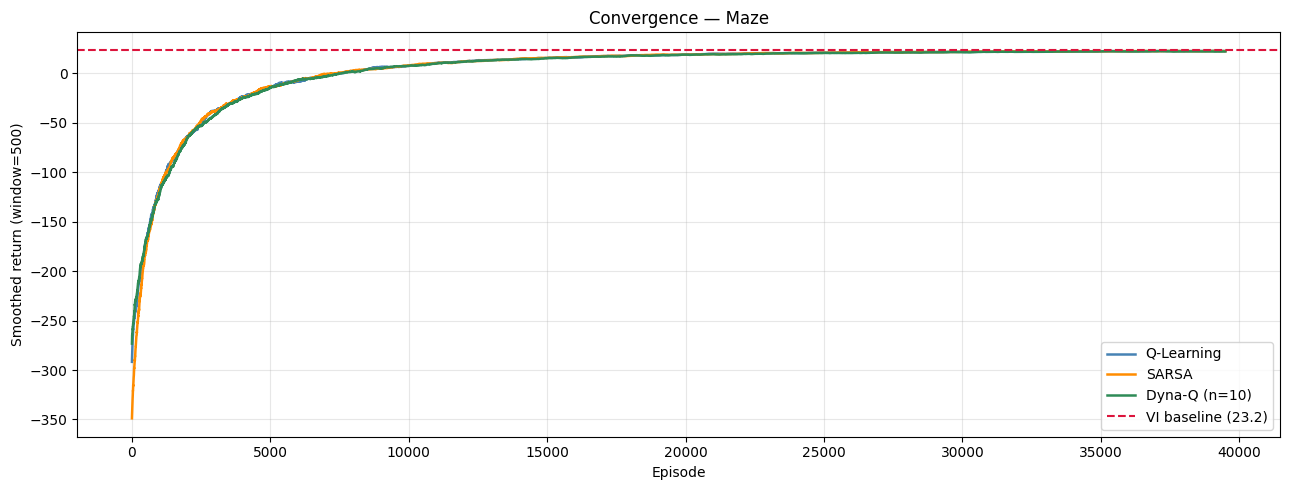

In [ ]:
def smooth(x, w=500):
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig, ax = plt.subplots(figsize=(13, 5))
for rewards, label, color in [
    (rewards_ql,    "Q-Learning",              "steelblue"),
    (rewards_sarsa, "SARSA",                   "darkorange"),
    (rewards_dynaq, f"Dyna-Q (n={N_PLANNING})", "seagreen"),
]:
    ax.plot(smooth(rewards), label=label, color=color, linewidth=1.8)

ax.axhline(metrics_vi["avg_return"], color="crimson", linestyle="--",
           linewidth=1.5, label=f"VI baseline ({metrics_vi['avg_return']:.1f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Smoothed return (window=500)")
ax.set_title("Convergence — Maze")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("maze_convergence.png", dpi=150)
plt.show()

## Evaluation metrics

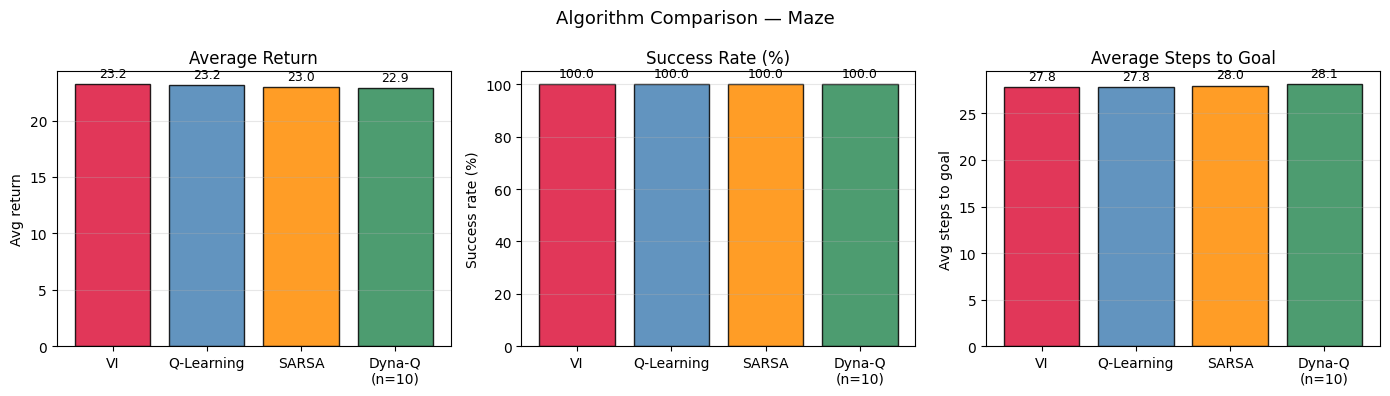

In [ ]:
algo_names  = ["VI", "Q-Learning", "SARSA", f"Dyna-Q\n(n={N_PLANNING})"]
all_metrics = [metrics_vi, metrics_ql, metrics_sarsa, metrics_dynaq]
colors      = ["crimson", "steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, values, ylabel, title in zip(
    axes,
    [[m["avg_return"]         for m in all_metrics],
     [m["success_rate"] * 100 for m in all_metrics],
     [m["avg_steps"]          for m in all_metrics]],
    ["Avg return", "Success rate (%)", "Avg steps to goal"],
    ["Average Return", "Success Rate (%)", "Average Steps to Goal"],
):
    bars = ax.bar(algo_names, values, color=colors, alpha=0.85, edgecolor="black")
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
plt.suptitle("Algorithm Comparison — Maze", fontsize=13)
plt.tight_layout()
plt.savefig("maze_metrics.png", dpi=150)
plt.show()

## Policy and Value comparison (2×2)

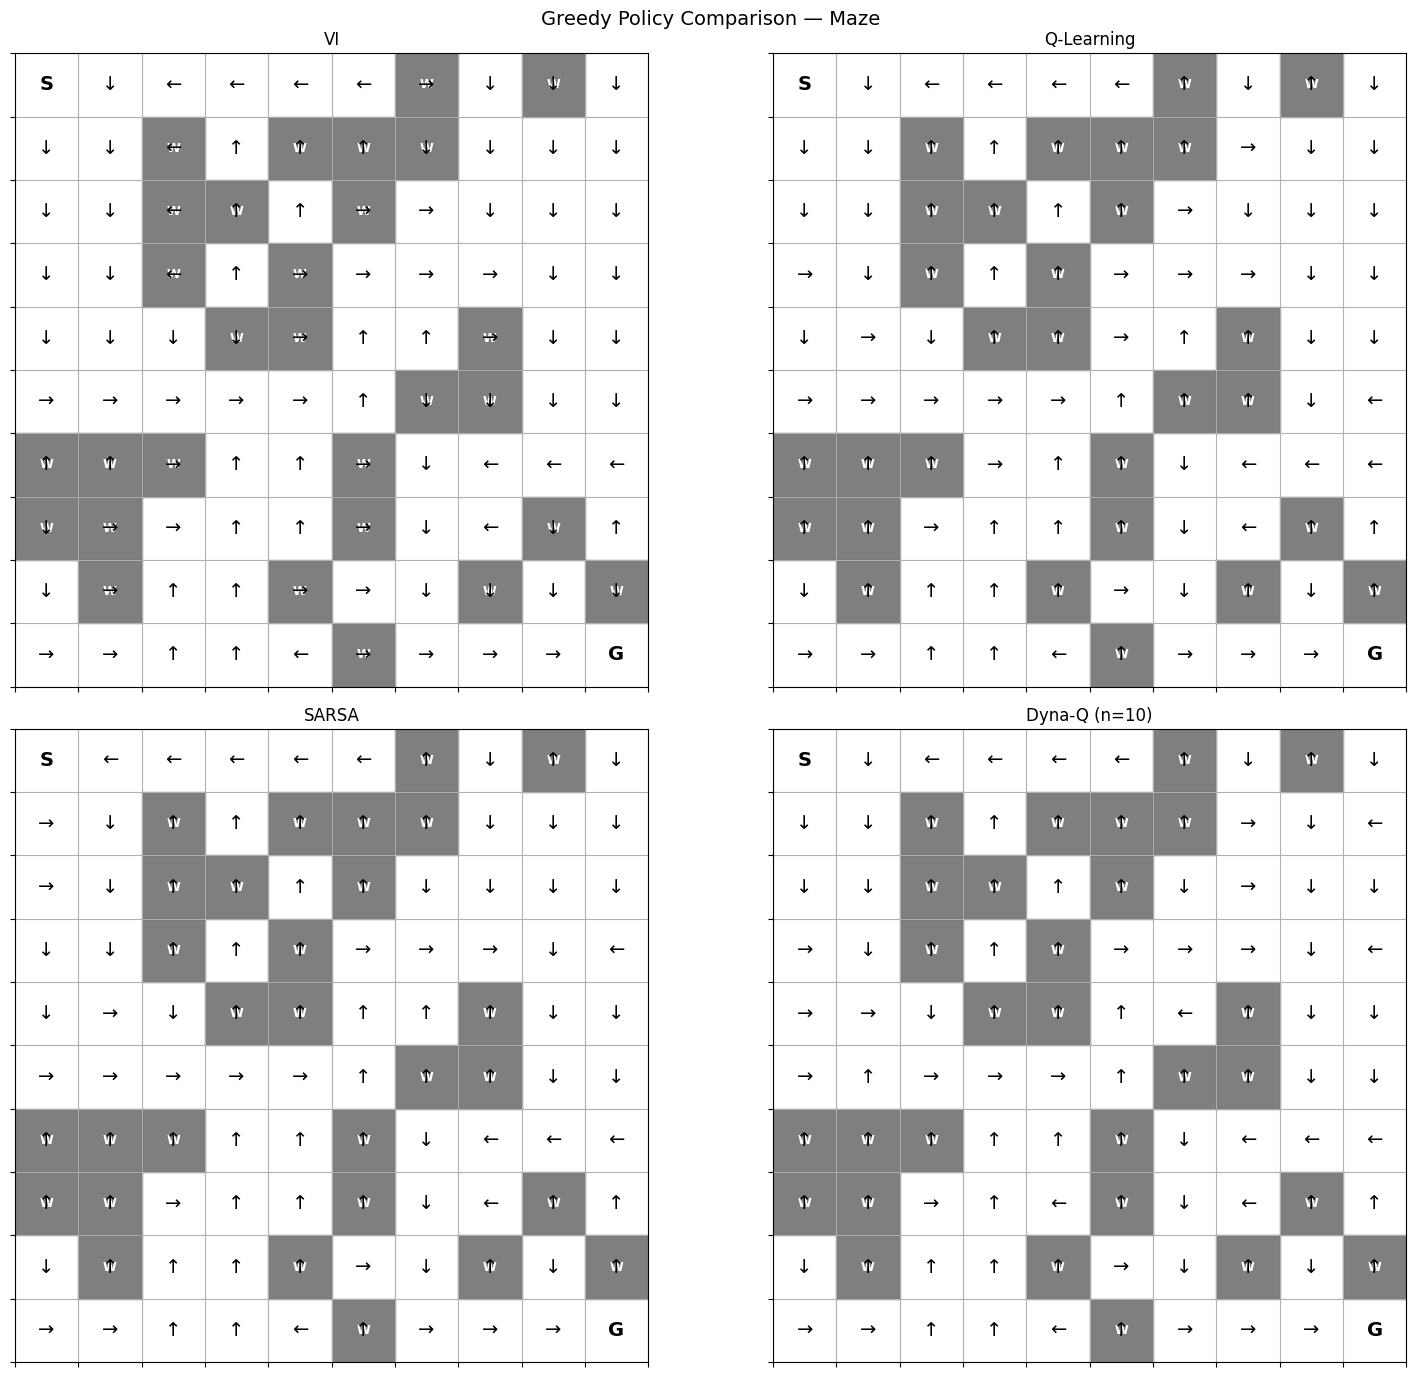

KeyboardInterrupt: 

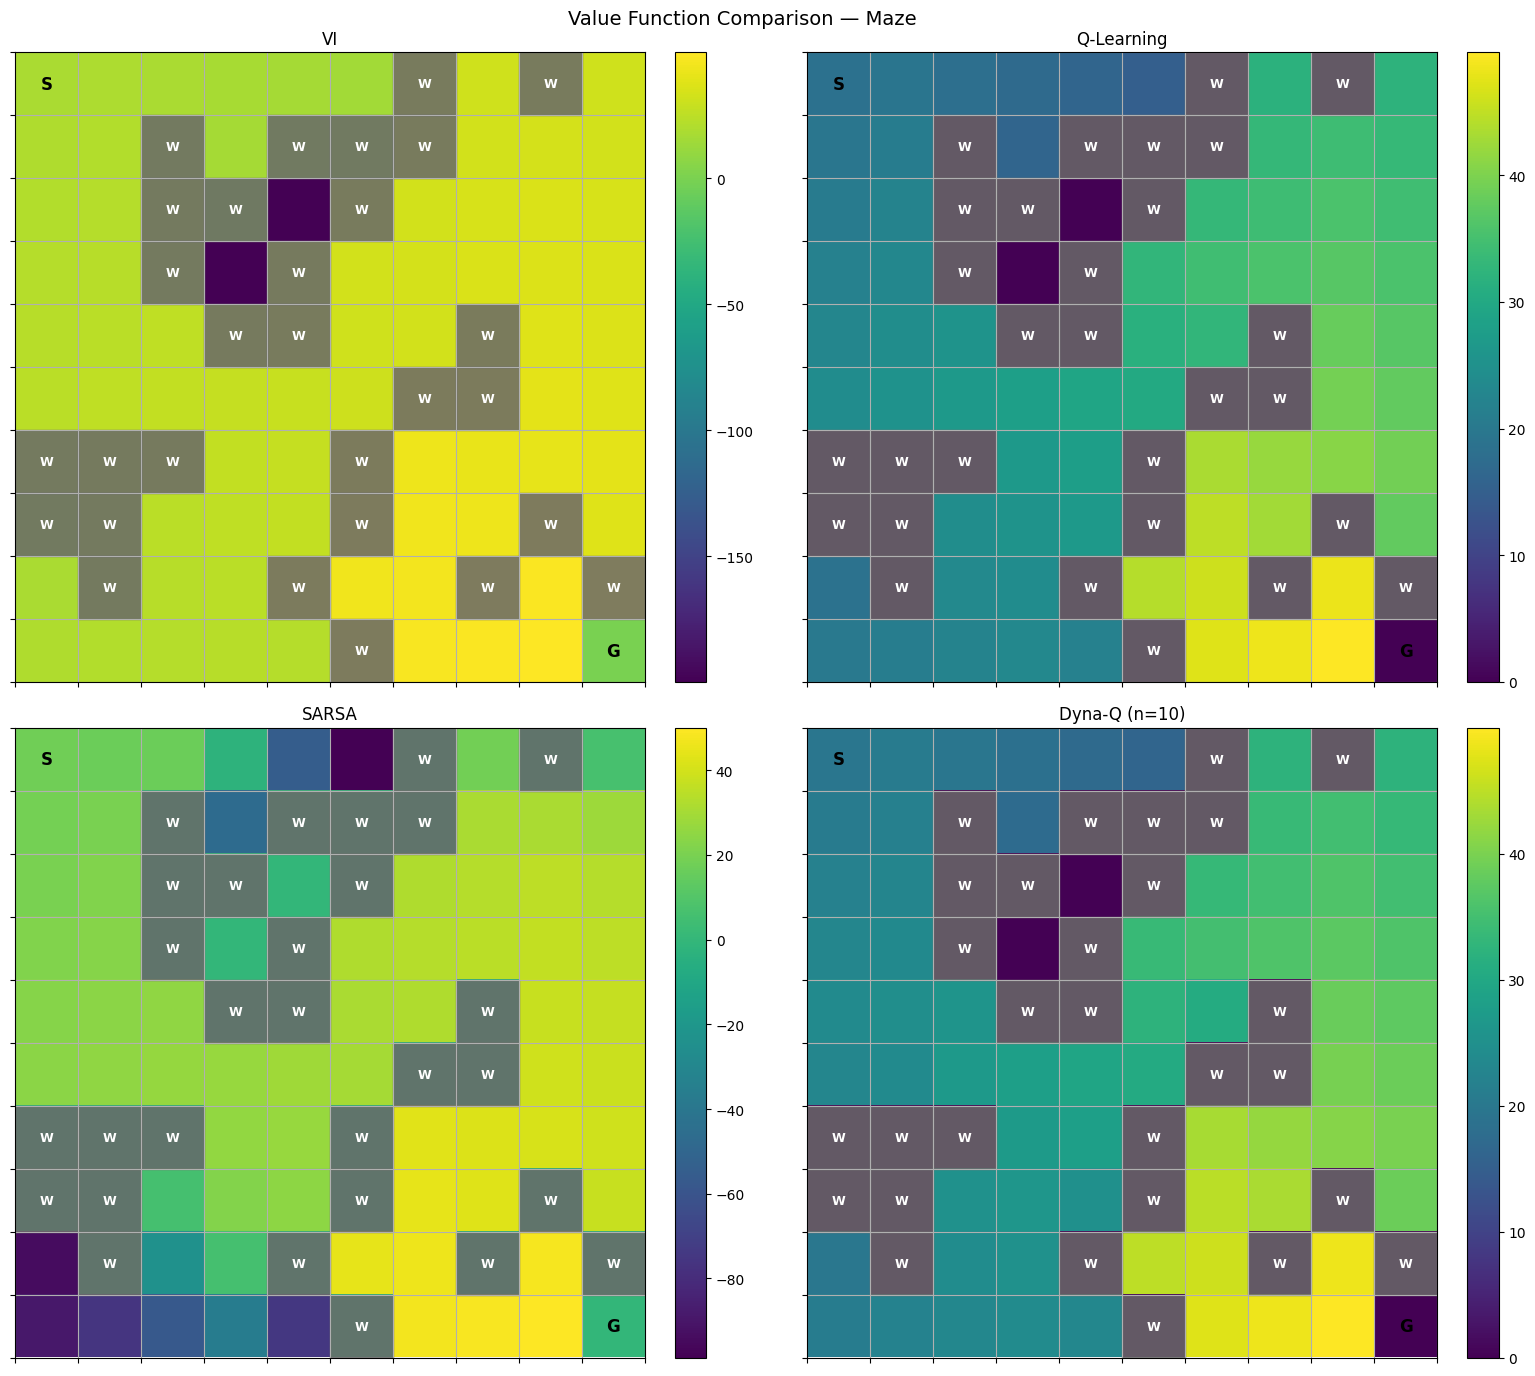

In [ ]:
pi_ql    = np.argmax(Q_ql,    axis=1).astype(float)
pi_sarsa = np.argmax(Q_sarsa, axis=1).astype(float)
pi_dynaq = np.argmax(Q_dynaq, axis=1).astype(float)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, policy, env_ref, title in zip(
    axes.flat,
    [pi_vi,   pi_ql,   pi_sarsa,  pi_dynaq],
    [env_vi,  env_ql,  env_sarsa, env_dynaq],
    ["VI", "Q-Learning", "SARSA", f"Dyna-Q (n={N_PLANNING})"],
):
    plot_policy(env_ref, policy, title=title, ax=ax)
plt.suptitle("Greedy Policy Comparison — Maze", fontsize=14)
plt.tight_layout()
plt.savefig("maze_policies.png", dpi=150)
plt.show()

V_ql    = np.max(Q_ql,    axis=1)
V_sarsa = np.max(Q_sarsa, axis=1)
V_dynaq = np.max(Q_dynaq, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, V, env_ref, title in zip(
    axes.flat,
    [V_vi,   V_ql,   V_sarsa,  V_dynaq],
    [env_vi, env_ql, env_sarsa, env_dynaq],
    ["VI", "Q-Learning", "SARSA", f"Dyna-Q (n={N_PLANNING})"],
):
    plot_value_heatmap(env_ref, V, title=title, ax=ax)
plt.suptitle("Value Function Comparison — Maze", fontsize=14)
plt.tight_layout()
plt.savefig("maze_values.png", dpi=150)
plt.show()

## Wall density comparison
How do algorithms perform as the grid gets more cluttered?
We sweep density from 5% (sparse, nearly open) to 35% (dense, many dead ends) and compare
average return and success rate for each algorithm.

In [ ]:
DENSITIES = [0.05, 0.10, 0.20, 0.30, 0.35]
density_results = {}

for d in DENSITIES:
    walls = random_walls(NUM_ROWS, NUM_COLS, density=d, start=START, goal=GOAL, seed=42)
    row = {}

    e = make_env(wall_fields=walls)
    V, _ = value_iteration(e, max_iterations=2000, gamma=GAMMA, threshold=1e-6)
    pi = greedy_policy_from_V(V, e, GAMMA)
    row["vi"] = evaluate(e, policy=pi, n_episodes=300, seed=SEED)

    for key, fn in [("ql", q_learning), ("sarsa", sarsa)]:
        e = make_env(wall_fields=walls)
        Q, _ = fn(e, **td_kwargs)
        row[key] = evaluate(e, Q=Q, n_episodes=300, seed=SEED)

    e = make_env(wall_fields=walls)
    Q, _ = dyna_q(e, **td_kwargs, n_planning_steps=N_PLANNING)
    row["dynaq"] = evaluate(e, Q=Q, n_episodes=300, seed=SEED)

    density_results[d] = row
    print(f"density={d:.0%}  " +
          "  ".join(f"{k}: ret={v['avg_return']:6.1f} suc={v['success_rate']:.2f}"
                    for k, v in row.items()))

In [ ]:
ALGO_KEYS   = ["vi",      "ql",          "sarsa",     "dynaq"]
ALGO_LABELS = ["VI",      "Q-Learning",  "SARSA",     f"Dyna-Q (n={N_PLANNING})"]
ALGO_COLORS = ["crimson", "steelblue",   "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for key, label, color in zip(ALGO_KEYS, ALGO_LABELS, ALGO_COLORS):
    returns = [density_results[d][key]["avg_return"]         for d in DENSITIES]
    success = [density_results[d][key]["success_rate"] * 100 for d in DENSITIES]
    pct = [d * 100 for d in DENSITIES]
    axes[0].plot(pct, returns, marker="o", label=label, color=color, linewidth=2)
    axes[1].plot(pct, success, marker="o", label=label, color=color, linewidth=2)

for ax, ylabel, title in zip(
    axes,
    ["Avg return (300 eval episodes)", "Success rate (%)"],
    ["Average Return vs Wall Density", "Success Rate vs Wall Density"],
):
    ax.set_xlabel("Wall density (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Effect of Wall Density on All Algorithms", fontsize=13)
plt.tight_layout()
plt.savefig("walls_density.png", dpi=150)
plt.show()

## Conclusions

### Random wall environment
- Randomly placed walls create a varied obstacle field: some regions are easy open corridors,
  others are dense clusters the agent must navigate around.
- Unlike a perfect maze, multiple paths exist, so algorithms compete on finding shorter ones.

### Value Iteration
- Unaffected by wall density up to the point where the grid becomes barely connected —
  Bellman sweeps propagate the goal reward through all free cells regardless of layout.
- Consistently the performance ceiling.

### Q-Learning vs SARSA with random walls
- Both converge faster than in a perfect maze because multiple paths mean
  reaching the goal is less rare early in training.
- **Q-Learning** tends to find the shorter paths first due to its greedy bootstrap.
- **SARSA** is more conservative, sometimes settling on a longer but safer route.

### Dyna-Q
- Planning steps are again most valuable when the path to the goal is long and
  early goal-reaching episodes are rare (high density).
- At low density the advantage shrinks because plain Q-Learning already reaches
  the goal frequently enough on its own.

### Wall density effect
- At low density (5–10%) all TD methods converge close to the VI baseline —
  the grid is nearly open and exploration is easy.
- Around 20–25% performance starts to diverge: Dyna-Q maintains higher return
  and success rate while Q-Learning and SARSA begin to struggle.
- Above 30% the grid becomes navigation-hard; success rates drop for TD methods
  while VI remains unaffected (it has the full model).
- The crossover point where Dyna-Q's advantage becomes significant is visible
  in the density line plots.